# Task 5

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Copy Structured Dataset from Drive to Colab

In [ ]:
!mkdir -p /content/data
!cp -r "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset" /content/data/

Install Dependencies

In [ ]:
!pip install tensorflow numpy matplotlib keras --quiet

GPU / CPU Detection

In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        mixed_precision.set_global_policy("mixed_float16")
        print("Using GPU with mixed precision")
    except RuntimeError as e:
        print(e)
else:
    print("GPU not available — using CPU")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU with mixed precision


Dataset Paths & Parameters

In [ ]:
# BASE_DIR = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset"
BASE_DIR = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 4   # Use smaller batch size if GPU memory is limited

print("Base Directory:", BASE_DIR)
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")

Base Directory: /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset
Image Size: (224, 224)
Batch Size: 4


Load Datasets

In [ ]:
import os
from PIL import Image

def find_corrupted_images(directory):
    corrupted = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(root, file)
                try:
                    with Image.open(path) as img:
                        img.verify()  # just verify, no full load
                except Exception:
                    corrupted.append(path)
    return corrupted

corrupted_images = find_corrupted_images("/content/data/structured dataset")

print(f"Found {len(corrupted_images)} corrupted or unreadable image(s).")
if len(corrupted_images) > 0:
    print("\nExamples:")
    print("\n".join(corrupted_images[:10]))

Found 0 corrupted or unreadable image(s).


In [ ]:
for img_path in corrupted_images:
    try:
        os.remove(img_path)
    except Exception as e:
        print(f"Error deleting {img_path}: {e}")

print("All corrupted images removed successfully!")

All corrupted images removed successfully!


In [ ]:
# ==============================================================
# LOAD DATASETS USING image_dataset_from_directory
# --------------------------------------------------------------
# Reads images from subfolders (each folder = one class)
# Auto-assigns numeric labels based on folder names
# Resizes all images to IMG_SIZE (e.g. 224x224)
# Groups images into batches of size BATCH_SIZE
#
# Training dataset:
#   shuffle=True  -> ensures randomization for learning
#
# Validation & Test datasets:
#   shuffle=False -> ensures consistent evaluation
# ==============================================================

import os

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 38104 files belonging to 44 classes.
Found 9458 files belonging to 44 classes.
Found 5741 files belonging to 44 classes.


Dataset Information

In [ ]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("\nClass names:")
for i, name in enumerate(class_names, 1):
    print(f"{i:2d}. {name}")

Number of classes: 44

Class names:
 1. Cassava___Bacterial_Blight_CBB
 2. Cassava___Brown_Streak_Disease_CBSD
 3. Cassava___Green_Mottle_CGM
 4. Cassava___Healthy
 5. Cassava___Mosaic_Disease_CMD
 6. Rice___BrownSpot
 7. Rice___Healthy
 8. Rice___Hispa
 9. Rice___LeafBlast
10. apple___apple_scab
11. apple___black_rot
12. apple___cedar_apple_rust
13. apple___healthy
14. cherry (including sour)___healthy
15. cherry (including sour)___powdery_mildew
16. corn (maize)___cercospora_leaf_spot_gray_leaf_spot
17. corn (maize)___common_rust
18. corn (maize)___healthy
19. corn (maize)___northern_leaf_blight
20. grape___black_rot
21. grape___esca_black_measles
22. grape___healthy
23. grape___leaf_blight_isariopsis_leaf_spot
24. orange___haunglongbing_citrus_greening
25. peach___bacterial_spot
26. peach___healthy
27. pepper, bell___bacterial_spot
28. pepper, bell___healthy
29. potato___early_blight
30. potato___healthy
31. potato___late_blight
32. squash___powdery_mildew
33. strawberry___healthy
3

Count Images in Each Dataset

In [ ]:
train_count = sum(1 for _ in train_ds.unbatch())
val_count = sum(1 for _ in val_ds.unbatch())
test_count = sum(1 for _ in test_ds.unbatch())

print("\nDataset Summary")
print("-" * 40)
print(f"Train images      : {train_count}")
print(f"Validation images : {val_count}")
print(f"Test images       : {test_count}")


Dataset Summary
----------------------------------------
Train images      : 38104
Validation images : 9458
Test images       : 5741


Visualize Sample Images

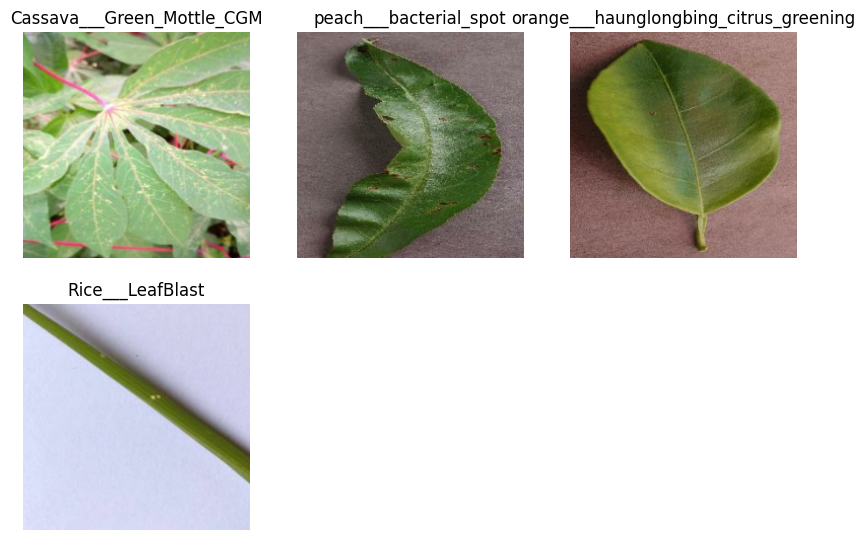

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Take 1 batch
    batch_size = images.shape[0]  # actual number of images in this batch
    grid_size = min(batch_size, 9)  # max 9 images shown
    for i in range(grid_size):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

# Task 6

Prefetch Batches

In [ ]:
from tensorflow.data import AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Prefetching enabled for train, validation, and test datasets.")

Prefetching enabled for train, validation, and test datasets.


Data Augmentation with TensorFlow

In [ ]:
from tensorflow.keras import layers, Sequential

data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(factor=0.2)  # adds brightness variation
])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


Calculate Class Weights

In [ ]:
import numpy as np
from collections import Counter

# Extract all labels from the training dataset
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(int(labels))

label_counts = Counter(all_labels)

# Compute class weights
max_count = max(label_counts.values())
class_weights = {cls: round(max_count / count, 2) for cls, count in label_counts.items()}

# Pretty output
print(f"{'Class Name':45s} | {'No. of Images':>14s} | {'Weight':>7s}")
print("-" * 75)

for cls_idx, count in sorted(label_counts.items()):
    class_name = class_names[cls_idx]
    weight = class_weights[cls_idx]
    print(f"{class_name:45s} | {count:14d} | {weight:7.2f}")

print("-" * 75)
print(f"Max class count = {max_count}")

Class Name                                    |  No. of Images |  Weight
---------------------------------------------------------------------------
Cassava___Bacterial_Blight_CBB                |            306 |   12.96
Cassava___Brown_Streak_Disease_CBSD           |            372 |   10.66
Cassava___Green_Mottle_CGM                    |            285 |   13.92
Cassava___Healthy                             |            370 |   10.72
Cassava___Mosaic_Disease_CMD                  |            240 |   16.52
Rice___BrownSpot                              |            377 |   10.52
Rice___Healthy                                |           1072 |    3.70
Rice___Hispa                                  |            408 |    9.72
Rice___LeafBlast                              |            562 |    7.06
apple___apple_scab                            |            454 |    8.74
apple___black_rot                             |            448 |    8.85
apple___cedar_apple_rust                      | 

# Task 7

Import Dependencies & Define Base Model

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
import tensorflow as tf

Declare the Base Model

In [ ]:
# Load EfficientNetB2 backbone
base_model = EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False   # freeze convolutional base
print("EfficientNetB2 base model loaded.")

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB2 base model loaded.


Declare the Model & Layers

In [ ]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = models.Model(inputs, outputs, name="EfficientNetB2_PlantDisease")

model.summary()

Model: "EfficientNetB2_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 44)             │        61,996 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,836,197 (29.89 MB)

 Trainable params: 64,812 (253.17 KB)

 Non-trainable params: 7,771,385 (29.65 MB)

Compile the Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Train the Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

drive_save_path = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models"
os.makedirs(drive_save_path, exist_ok=True)

checkpoint_path = os.path.join(drive_save_path, "efficientnetb2_leaf_model.keras")

early_stop = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

#Use the new Keras format to avoid pickling errors
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
9525/9526 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5442 - loss: 1.7244
Epoch 1: val_accuracy improved from -inf to 0.87291, saving model to /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/efficientnetb2_leaf_model.keras
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 442s 43ms/step - accuracy: 0.5443 - loss: 1.7242 - val_accuracy: 0.8729 - val_loss: 0.4026
Epoch 2/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7580 - loss: 0.7870
Epoch 2: val_accuracy improved from 0.87291 to 0.88243, saving model to /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/efficientnetb2_leaf_model.keras
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 393s 41ms/step - accuracy: 0.7580 - loss: 0.7870 - val_accuracy: 0.8824 - val_loss: 0.3720
Epoch 3/10
9525/9526 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7780 - loss: 0.7203
Epoch 3: val_accuracy improved from 0.88243 to 0.88296, saving model to /content/drive/MyDrive/AI Driven Web

# Task 8

Evaluate the Model on Test Data

In [ ]:
# Evaluate trained model
test_loss, test_acc = model.evaluate(test_ds)

# Convert to percentage
test_accuracy_percent = test_acc * 100
test_loss_percent = test_loss * 100

print("\nFINAL MODEL EVALUATION (on Test Dataset)")
print("-" * 60)
print(f"Test Accuracy : {test_accuracy_percent:.2f}%")
print(f"Test Loss     : {test_loss_percent:.2f}%")

1436/1436 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - accuracy: 0.7557 - loss: 0.8269

FINAL MODEL EVALUATION (on Test Dataset)
------------------------------------------------------------
Test Accuracy : 86.94%
Test Loss     : 43.03%


Plot Accuracy & Loss Graphs

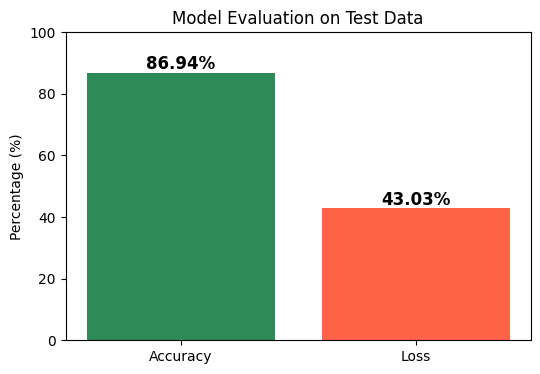

In [ ]:
import matplotlib.pyplot as plt

# Data for plotting
metrics = ['Accuracy', 'Loss']
values = [test_accuracy_percent, test_loss_percent]
colors = ['seagreen', 'tomato']

plt.figure(figsize=(6,4))
plt.bar(metrics, values, color=colors)
plt.title("Model Evaluation on Test Data")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontsize=12, fontweight='bold')
plt.show()

Optimizations

In [ ]:
#Fine tuning the base model
# Unfreeze top layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-40]:  # Freeze all but last 40 layers
    layer.trainable = False

# Re-compile model with smaller LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train fine-tuned model
FINE_TUNE_EPOCHS = 10
STEPS_PER_EPOCH = 1500
VALIDATION_STEPS = 250

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

print("Fine-tuning complete.")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6327 - loss: 6.9787
Epoch 1: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 124s 60ms/step - accuracy: 0.6327 - loss: 6.9781 - val_accuracy: 0.5460 - val_loss: 1.5980
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7252 - loss: 4.5173
Epoch 2: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 57ms/step - accuracy: 0.7252 - loss: 4.5173 - val_accuracy: 0.4770 - val_loss: 1.7868
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7517 - loss: 3.9177
Epoch 3: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.7517 - loss: 3.9177 - val_accuracy: 0.5080 - val_loss: 2.0334
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7729 - loss: 3.4859
Epoch 4: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.7729 - loss: 3.48

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 7: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.7900 - loss: 3.6498 - val_accuracy: 0.5210 - val_loss: 1.6607
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8041 - loss: 3.2375
Epoch 8: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 88s 58ms/step - accuracy: 0.8041 - loss: 3.2375 - val_accuracy: 0.5240 - val_loss: 1.3804
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8137 - loss: 3.1619
Epoch 9: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 87s 58ms/step - accuracy: 0.8137 - loss: 3.1618 - val_accuracy: 0.6000 - val_loss: 1.4207
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8172 - loss: 2.9502
Epoch 10: val_accuracy did not improve from 0.90156
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 56ms/step - accuracy: 0.8172 - loss: 2.9501 - val_accuracy: 0.6400 - val_loss: 1.4600
Fine-tuning complete.


In [ ]:
#Use Learning Rate Scheduler - Helps model converge more smoothly.

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-7
)

In [ ]:
#Regularization - Add dropout or L2 weight decay to reduce overfitting.
x = layers.Dropout(0.5)(x)  # increase dropout rate slightly

Final Evaluation After Optimizations

In [ ]:
#Evaluate the optimized model on the test dataset
final_test_loss, final_test_acc = model.evaluate(test_ds)

# Convert to percentage
final_acc_percent = final_test_acc * 100
final_loss_percent = final_test_loss * 100

print("\nFINAL MODEL PERFORMANCE AFTER OPTIMIZATIONS")
print("-" * 65)
print(f"Final Test Accuracy : {final_acc_percent:.2f}%")
print(f"Final Test Loss     : {final_loss_percent:.2f}%")
print("-" * 65)

# (Optional) Compare to previous accuracy if you saved it earlier
try:
    print(f"Accuracy Improvement : {final_acc_percent - test_accuracy_percent:.2f}%")
except:
    print("Accuracy Improvement : Not Available (previous accuracy not stored)")

1436/1436 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.7426 - loss: 1.0055

FINAL MODEL PERFORMANCE AFTER OPTIMIZATIONS
-----------------------------------------------------------------
Final Test Accuracy : 87.44%
Final Test Loss     : 47.61%
-----------------------------------------------------------------
Accuracy Improvement : 0.51%


Visualize the Final Performance

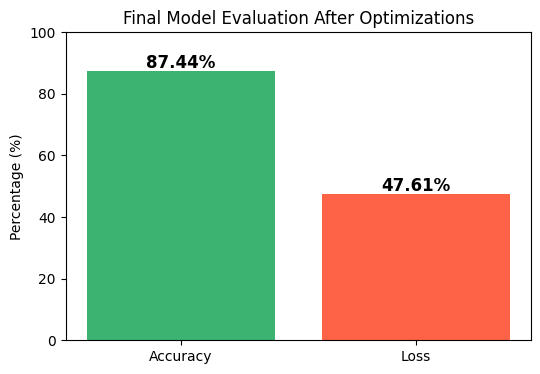

In [ ]:
import matplotlib.pyplot as plt

# Create bar chart
metrics = ['Accuracy', 'Loss']
values = [final_acc_percent, final_loss_percent]
colors = ['mediumseagreen', 'tomato']

plt.figure(figsize=(6,4))
bars = plt.bar(metrics, values, color=colors)
plt.title("Final Model Evaluation After Optimizations")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

# Add value labels on bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.2f}%",
             ha='center', fontsize=12, fontweight='bold')

plt.show()

Save the Optimized Model

In [ ]:
import os

save_dir = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models"
os.makedirs(save_dir, exist_ok=True)

fine_tuned_model_path = os.path.join(save_dir, "efficientnetb2_leaf_model_finetuned.keras")
model.save(fine_tuned_model_path)

print(f"Fine-tuned model saved at: {fine_tuned_model_path}")

Fine-tuned model saved at: /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/efficientnetb2_leaf_model_finetuned.keras
